In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\PC-LOQ\Desktop\internship\day9()\IMDB Dataset.csv\IMDB Dataset.csv")

print(df.head())
print(df.shape)
print(df.columns)

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
(50000, 2)
Index(['review', 'sentiment'], dtype='object')


In [2]:
print(df.isnull().sum())

print(df.info())
print(df.describe())

print(df["sentiment"].value_counts())

review       0
sentiment    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


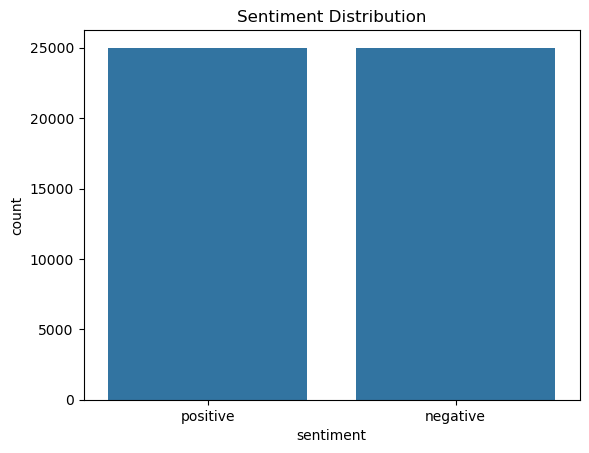

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x="sentiment",
    data=df
)
plt.title("Sentiment Distribution")
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["sentiment"] = encoder.fit_transform(df["sentiment"])
print(df.head())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1


In [5]:
import re
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to C:\Users\PC-
[nltk_data]     LOQ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words("english"))

In [7]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [8]:
df["review"] = df["review"].apply(clean_text)
print(df.head())

                                              review  sentiment
0  one review mention watch oz episod hook right ...          1
1  wonder littl product film techniqu unassum old...          1
2  thought wonder way spend time hot summer weeke...          1
3  basic famili littl boy jake think zombi closet...          0
4  petter mattei love time money visual stun film...          1


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000
)
X = vectorizer.fit_transform(df["review"])
y = df["sentiment"]
print(X.shape)

(50000, 5000)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42
)

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(
    y_test,
    pred_nb
)
print("Naive Bayes Accuracy =", acc_nb)

Naive Bayes Accuracy = 0.8514


In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(
    y_test,
    pred_lr
)
print("Logistic Regression Accuracy =", acc_lr)

Logistic Regression Accuracy = 0.8864


In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(
    y_test,
    pred_knn
)
print("KNN Accuracy =", acc_knn)

KNN Accuracy = 0.7613


In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(
    y_test,
    pred_dt
)
print("Decision Tree Accuracy =", acc_dt)

Decision Tree Accuracy = 0.7215


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(
    y_test,
    pred_rf
)
print("Random Forest Accuracy =", acc_rf)

Random Forest Accuracy = 0.8485


In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, pred_xgb)

print("XGBoost Accuracy =", acc_xgb)

XGBoost Accuracy = 0.8602


In [21]:
results = pd.DataFrame({

    "Model":[
        "Naive Bayes",
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        acc_nb,
        acc_lr,
        acc_knn,
        acc_dt,
        acc_rf,
        acc_xgb
    ]
})
print(results)

                 Model  Accuracy
0          Naive Bayes    0.8514
1  Logistic Regression    0.8864
2                  KNN    0.7613
3        Decision Tree    0.7215
4        Random Forest    0.8485
5              XGBoost    0.8602


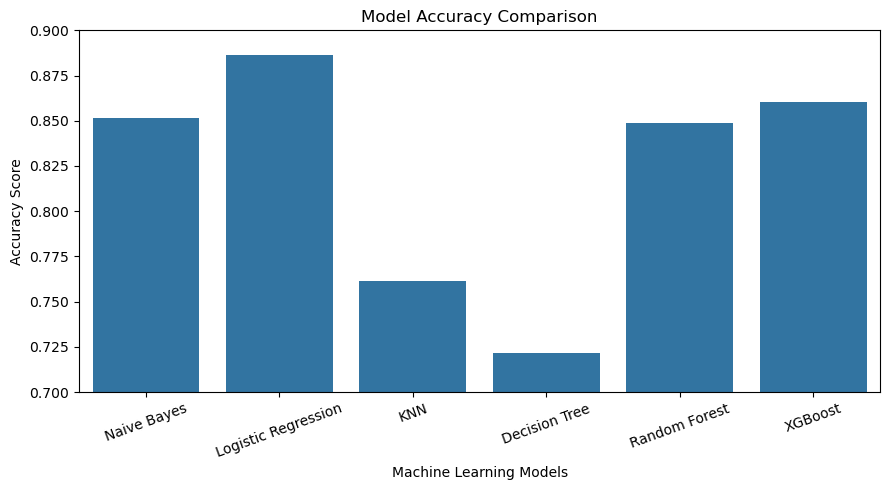

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=20)
plt.ylim(0.70,0.90)
plt.tight_layout()
plt.show()